# Sales Performance & Business Insights Analysis

## Objective
This project aims to analyze sales performance, customer behavior, and regional trends in order to generate business insights and strategic recommendations.
    

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Overview

The dataset contains transactional sales data including customer information, product categories, sales, profit, discounts, and regional performance.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()

# Executive KPI Analysis

In [9]:
total_sales = df['Sales'].sum()
print(f"Total Revenue: ${total_sales:,.2f}")

Total Revenue: $2,297,200.86


In [10]:
total_profit = df['Profit'].sum()
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [11]:
profit_margin = (total_profit / total_sales) * 100
print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 12.47%


In [12]:
total_orders = df['Order ID'].nunique()
print(f"Total Orders: {total_orders}")

Total Orders: 5009


In [13]:
total_customers = df['Customer ID'].nunique()
print(f"Total Customers: {total_customers}")

Total Customers: 793


In [14]:
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
print(f"Average Order Value: ${avg_order_value:,.2f}")

Average Order Value: $458.61


# Executive Summary
Overall the numbers look decent، around $2.3M in revenue and $286K in profit gives a margin of about 12.47%. There were 793 unique customers placing over 5,000 orders which suggests people are coming back, not just one-time buyers. The average order value sitting at $458 tells me customers usually buy more than one thing per order. Still, 12% margin isn't huge so there's definitely room to improve, especially if we can fix the discount issue


# Sales Trend Analysis

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month_name()

In [16]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

monthly_sales

,Month,Sales
0,April,137762.1286
1,August,159044.0630
2,December,325293.5035
3,February,59751.2514
4,January,94924.8356
5,July,147238.0970
6,June,152718.6793
7,March,205005.4888
8,May,155028.8117
9,November,352461.0710


In [17]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

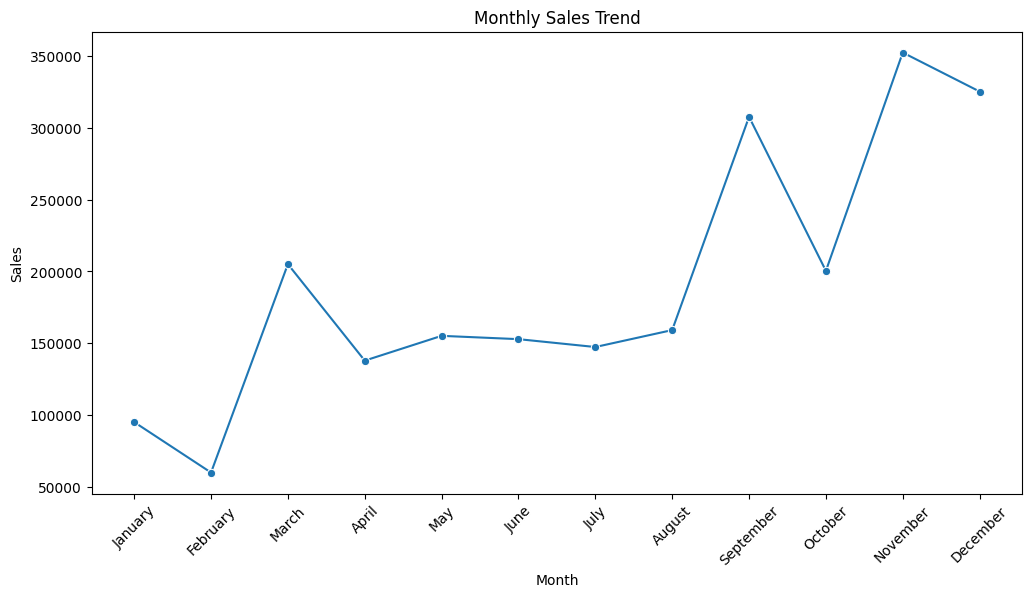

In [18]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Sales',
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.savefig("monthly_sales_trend.png", bbox_inches="tight")

plt.show()

## Key Findings

- November recorded the highest sales performance throughout the year.
- February generated the lowest sales volume.
- Sales increased significantly during the fourth quarter (Q4).
- The business demonstrates a clear seasonal sales pattern.

## Executive Insight

Monthly Sales Trend
November was clearly the best month، the jump in Q4 is hard to miss. February being the lowest makes sense honestly, it's usually a slow month for most businesses. This pattern tells me seasonal campaigns could make a real difference if timed right.

In [19]:
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

category_performance

,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


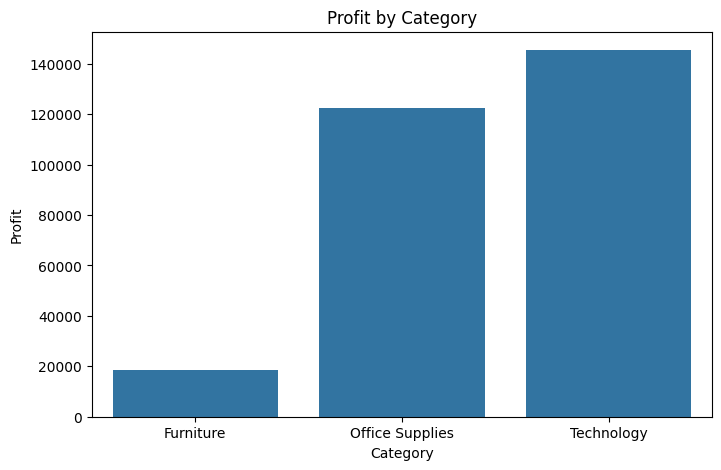

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_performance,
    x='Category',
    y='Profit'
)

plt.title('Profit by Category')
plt.savefig("profit_by_category.png", bbox_inches="tight")

plt.show()

## Executive Insight

Technology is doing really well profit-wise. What caught my attention was Furniture، the sales aren't bad but the profit is surprisingly low. Office Supplies is just steady and consistent, nothing crazy but reliable.

In [21]:
subcategory_performance = df.groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

subcategory_performance.sort_values(
    by='Profit',
    ascending=False
)

,Sub-Category,Sales,Profit
6,Copiers,149528.0300,55617.8249
13,Phones,330007.0540,44515.7306
0,Accessories,167380.3180,41936.6357
12,Paper,78479.2060,34053.5693
3,Binders,203412.7330,30221.7633
5,Chairs,328449.1030,26590.1663
14,Storage,223843.6080,21278.8264
1,Appliances,107532.1610,18138.0054
9,Furnishings,91705.1640,13059.1436
7,Envelopes,16476.4020,6964.1767


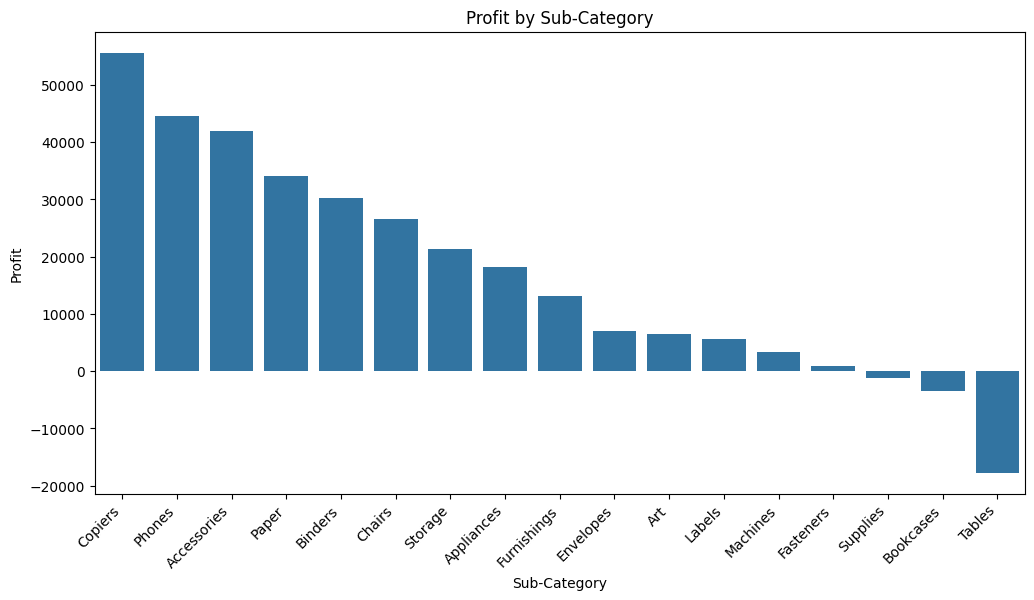

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=subcategory_performance.sort_values(by='Profit', ascending=False),
    x='Sub-Category',
    y='Profit'
)
plt.title('Profit by Sub-Category')
plt.xticks(rotation=45, ha='right')
plt.savefig("profit_subcategory.png", bbox_inches="tight")
plt.show()

## Executive Insight

Copiers and Phones are the clear winners here. Tables and Bookcases are actually losing money which is a bit concerning — probably worth looking at whether the discounts on these are too high.

In [23]:
region_performance = df.groupby('Region').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

region_performance.sort_values(by='Sales', ascending=False)

,Region,Sales,Profit
3,West,725457.8245,108418.4489
1,East,678781.2400,91522.7800
0,Central,501239.8908,39706.3625
2,South,391721.9050,46749.4303


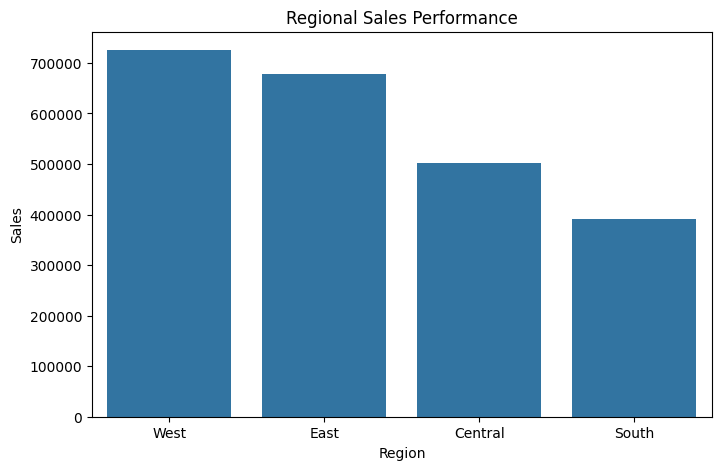

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=region_performance.sort_values(by='Sales', ascending=False),
    x='Region',
    y='Sales'
)
plt.title('Regional Sales Performance')
plt.savefig("regional_sales.png", bbox_inches="tight")
plt.show()

## Executive Insight

West is leading which wasn't too surprising. What stood out was Central — higher sales than South but lower profit, something seems off there, maybe pricing or discounts.

In [25]:
segment_performance = df.groupby('Segment').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

segment_performance

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


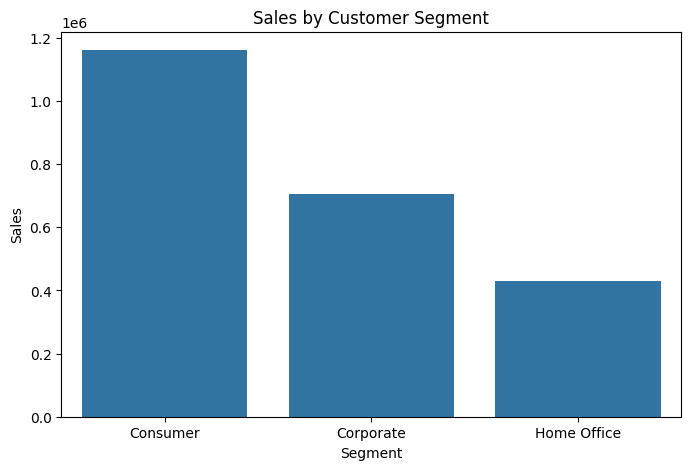

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=segment_performance,
    x='Segment',
    y='Sales'
)
plt.title('Sales by Customer Segment')
plt.savefig("segment_sales.png", bbox_inches="tight")
plt.show()

## Executive Insight

Consumer segment is the biggest group and also the most profitable. Nothing too unexpected here but good to confirm.


In [27]:
discount_analysis = df.groupby('Discount').agg({
    'Sales':'sum',
    'Profit':'sum'
}).reset_index()

discount_analysis.sort_values('Discount')

,Discount,Sales,Profit
0,0.00,1.087908e+06,320987.6032
1,0.10,5.436935e+04,9029.1770
2,0.15,2.755852e+04,1418.9915
3,0.20,7.645944e+05,90337.3060
4,0.30,1.032267e+05,-10369.2774
5,0.32,1.449346e+04,-2391.1377
6,0.40,1.164178e+05,-23057.0504
7,0.45,5.484974e+03,-2493.1111
8,0.50,5.891854e+04,-20506.4281
9,0.60,6.644700e+03,-5944.6552


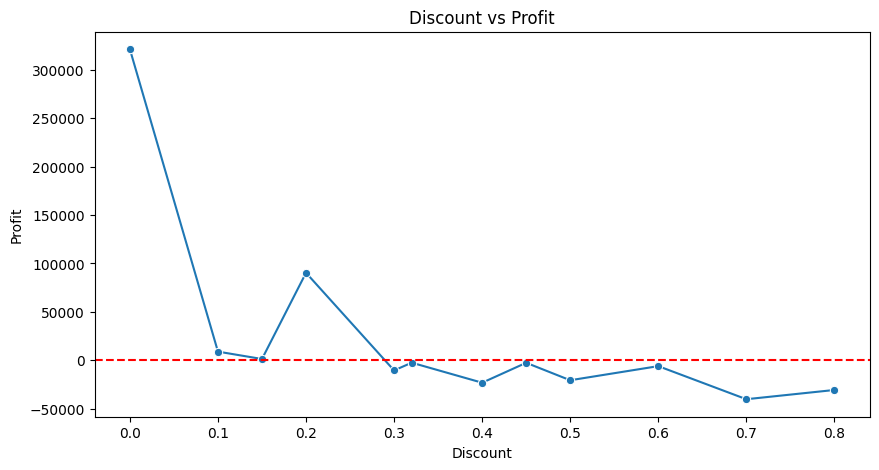

In [28]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=discount_analysis,
    x='Discount',
    y='Profit',
    marker='o'
)
plt.axhline(0, color='red', linestyle='--')
plt.title('Discount vs Profit')
plt.savefig("discount_profit.png", bbox_inches="tight")
plt.show()

## Executive Insight

This one was interesting، once discounts go above 30% the profit just drops into negative. So the discounting strategy definitely needs a second look, especially for the products that are already struggling.

## Final Recommendations

Based on everything in this analysis, here are a few things worth considering:

- Stop heavily discounting Furniture — especially Tables and Bookcases, they're already losing money
- Focus retention efforts on the Consumer segment since they're the biggest and most profitable group
- Q4 is clearly the strongest period, so it makes sense to plan bigger campaigns around that time
- The Central region needs a closer look — the sales are there but the profit isn't adding up
- Investing more in Technology products seems like a safe bet given how consistently they perform

## Conclusion

Overall this analysis gave a pretty clear picture of where the business is doing well and where it's struggling. Technology is the strongest category by far, while Furniture، especially Tables and Bookcases، is actually losing money. The West region is leading, and the Central region has a weird gap between sales and profit that's worth investigating. The discount finding was probably the most useful one، anything above 30% seems to hurt more than it helps. Hopefully these findings can help with pricing and planning decisions going forward.